In [11]:
import pandas as pd
import matplotlib.pyplot as plt


In [36]:
df = pd.read_csv("train.csv")

our_df = df[["SalePrice","GrLivArea","YearBuilt","MoSold","YrSold","Neighborhood","LotArea","OverallQual","OverallCond","SaleType","SaleCondition"]].copy()
our_df['Area_m2'] = our_df['GrLivArea'] * 0.092903
our_df['LotArea_m2'] = our_df['LotArea'] * 0.092903
our_df['House_Age'] = our_df['YrSold'] - our_df['YearBuilt']
our_df

,SalePrice,GrLivArea,YearBuilt,MoSold,YrSold,Neighborhood,LotArea,OverallQual,OverallCond,SaleType,SaleCondition,Area_m2,LotArea_m2,House_Age
0,208500,1710,2003,2,2008,CollgCr,8450,7,5,WD,Normal,158.864130,785.030350,5
1,181500,1262,1976,5,2007,Veenker,9600,6,8,WD,Normal,117.243586,891.868800,31
2,223500,1786,2001,9,2008,CollgCr,11250,7,5,WD,Normal,165.924758,1045.158750,7
3,140000,1717,1915,2,2006,Crawfor,9550,7,5,WD,Abnorml,159.514451,887.223650,91
4,250000,2198,2000,12,2008,NoRidge,14260,8,5,WD,Normal,204.200794,1324.796780,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,175000,1647,1999,8,2007,Gilbert,7917,6,5,WD,Normal,153.011241,735.513051,8
1456,210000,2073,1978,2,2010,NWAmes,13175,6,6,WD,Normal,192.587919,1223.997025,32
1457,266500,2340,1941,5,2010,Crawfor,9042,7,9,WD,Normal,217.393020,840.028926,69
1458,142125,1078,1950,4,2010,NAmes,9717,5,6,WD,Normal,100.149434,902.738451,60


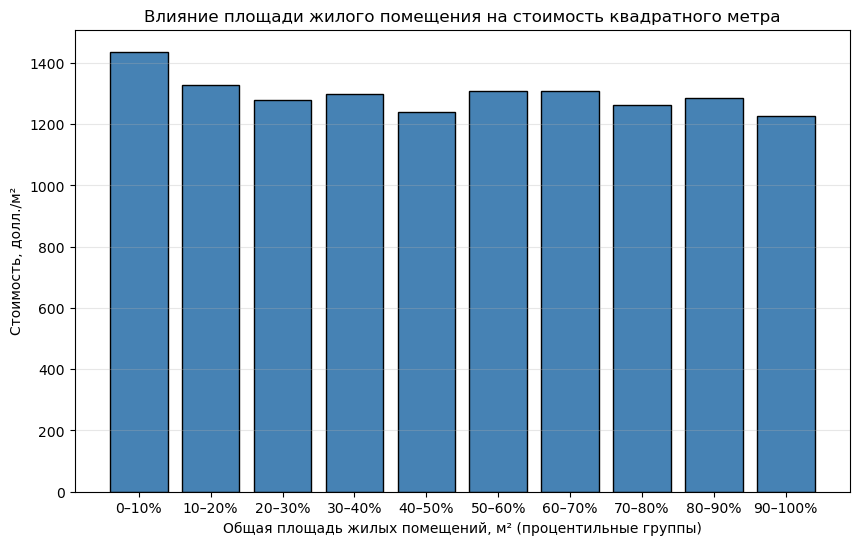

In [13]:
our_df['Area_group'] = pd.qcut(our_df['Area_m2'], q=10, labels=False)

grouped = our_df.groupby('Area_group')[['SalePrice', 'Area_m2']].mean()
avg_price_per_m2 = (grouped['SalePrice'] / grouped['Area_m2']).round(4)

group_bounds = our_df.groupby('Area_group')['Area_m2'].agg(['min', 'max'])
labels = [f"{i*10}–{(i+1)*10}%" for i in range(10)]

plt.figure(figsize=(10, 6))
plt.bar(labels, avg_price_per_m2, color='steelblue', edgecolor='black')
plt.xlabel("Общая площадь жилых помещений, м² (процентильные группы)")
plt.ylabel("Стоимость, долл./м²")
plt.title("Влияние площади жилого помещения на стоимость квадратного метра")
plt.grid(axis='y', alpha=0.3)
plt.show()

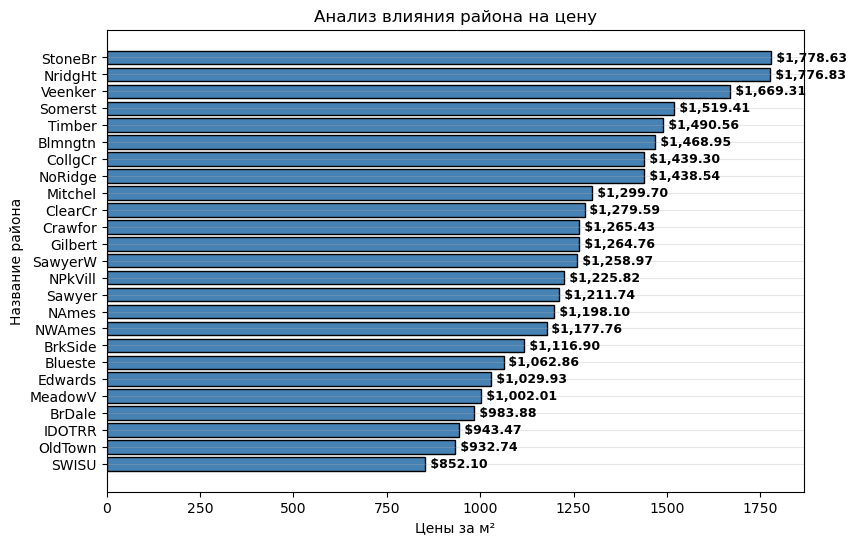

In [14]:
all_neighborhoods = set(our_df["Neighborhood"])
prices = []
for neighbor in all_neighborhoods:
    curr_neighbor = our_df[our_df["Neighborhood"] == neighbor]
    price_nighbor = round(
        float(curr_neighbor["SalePrice"].mean() / curr_neighbor["Area_m2"].mean()), 4
    )
    prices.append(price_nighbor)
sorted_data = sorted(zip(prices,all_neighborhoods))
sorted_prices , sorted_neighbors  = zip(*sorted_data)
plt.figure(figsize=(9, 6))
plt.barh(list(sorted_neighbors), sorted_prices, color="steelblue", edgecolor="black")
plt.xlabel("Цены за м²")
plt.ylabel("Название района")
plt.title("Анализ влияния района на цену")
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(sorted_prices):
    plt.text(v + 2, i, f" ${v:,.2f}", va="center", fontsize=9, fontweight="bold")


plt.show()

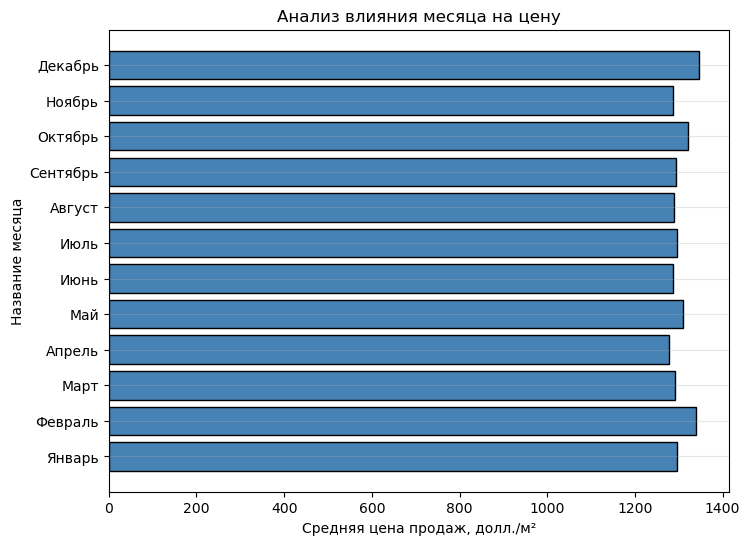

In [15]:
months = [
    "Январь", "Февраль", "Март", "Апрель", 
    "Май", "Июнь", "Июль", "Август", 
    "Сентябрь", "Октябрь", "Ноябрь", "Декабрь"
]
prices = []
for month in range(1,13):
    curr_month = our_df[our_df["MoSold"] == month]
    month_price = round(float((curr_month["SalePrice"] / curr_month["Area_m2"]).mean()) , 4)
    prices.append(month_price)

plt.figure(figsize=(8, 6))
plt.barh(months, prices, color="steelblue", edgecolor="black")
plt.xlabel("Средняя цена продаж, долл./м²")
plt.ylabel("Название месяца")
plt.title("Анализ влияния месяца на цену")
plt.grid(axis="y", alpha=0.3)



plt.show()

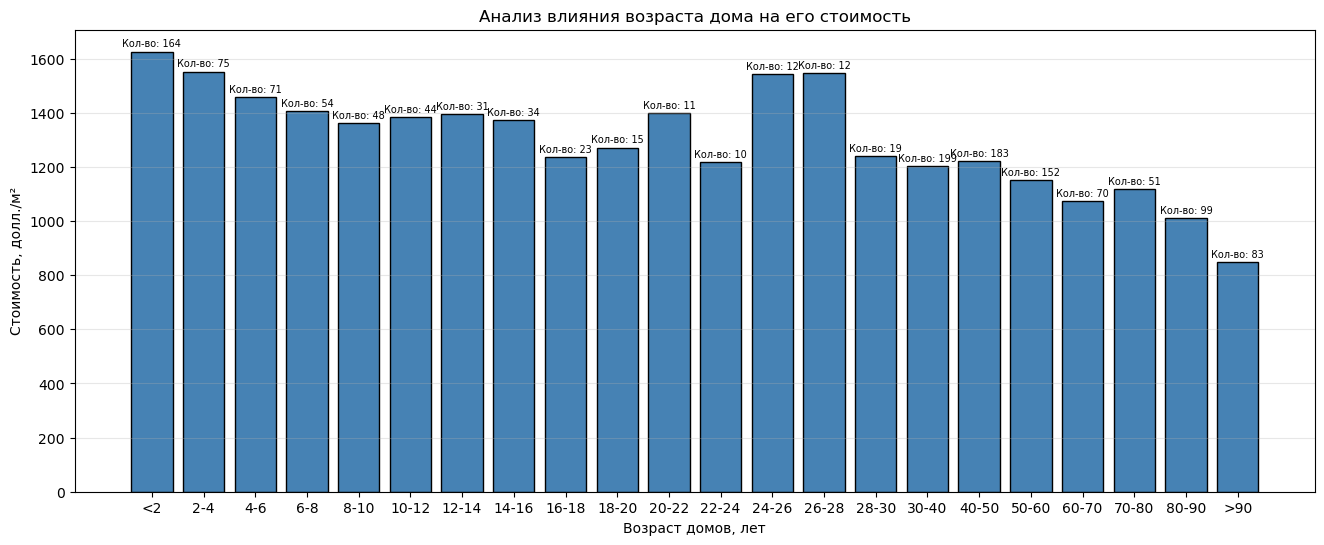

In [16]:
bins = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 40, 50, 60, 70, 80, 90, float('inf')]
labels = ["<2", "2-4", "4-6", "6-8", "8-10", "10-12", "12-14", "14-16", "16-18", "18-20", "20-22", "22-24", "24-26", "26-28", "28-30", "30-40", "40-50", "50-60", "60-70", "70-80", "80-90", ">90"]
our_df['Age_group'] = pd.cut(our_df['House_Age'], bins=bins, labels=labels, right=False)

grouped = our_df.groupby('Age_group', observed=False)[['SalePrice', 'Area_m2']].mean()
prices = (grouped['SalePrice'] / grouped['Area_m2']).round(4)

counts = our_df.groupby('Age_group', observed=False).size()

plt.figure(figsize=(16, 6))
bars = plt.bar(prices.index, prices, color="steelblue", edgecolor="black")

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10.5, 
             f'Кол-во: {count}', ha='center', va='bottom', fontsize=7)
plt.xlabel("Возраст домов, лет")
plt.ylabel("Стоимость, долл./м²")
plt.title("Анализ влияния возраста дома на его стоимость")
plt.grid(axis="y", alpha=0.3)
plt.show()

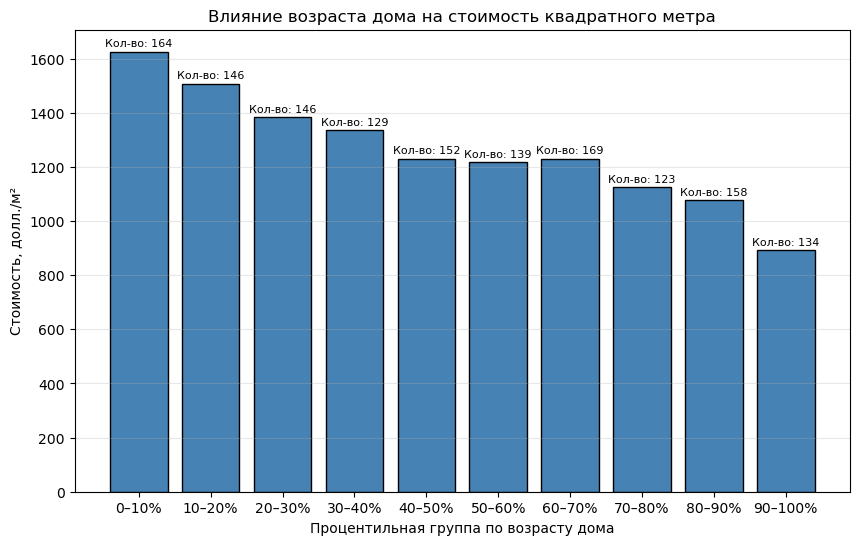

In [17]:
our_df['Age_group'] = pd.qcut(our_df['House_Age'], q=10, labels=False)

grouped = our_df.groupby('Age_group')[['SalePrice', 'Area_m2']].mean()
prices = (grouped['SalePrice'] / grouped['Area_m2']).round(4)

counts = our_df.groupby('Age_group').size()

labels = [f"{i*10}–{(i+1)*10}%" for i in range(10)]

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, prices, color="steelblue", edgecolor="black")

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10.5,
             f'Кол-во: {count}', ha='center', va='bottom', fontsize=8)

plt.xlabel("Процентильная группа по возрасту дома")
plt.ylabel("Стоимость, долл./м²")
plt.title("Влияние возраста дома на стоимость квадратного метра")
plt.grid(axis="y", alpha=0.3)
plt.show()

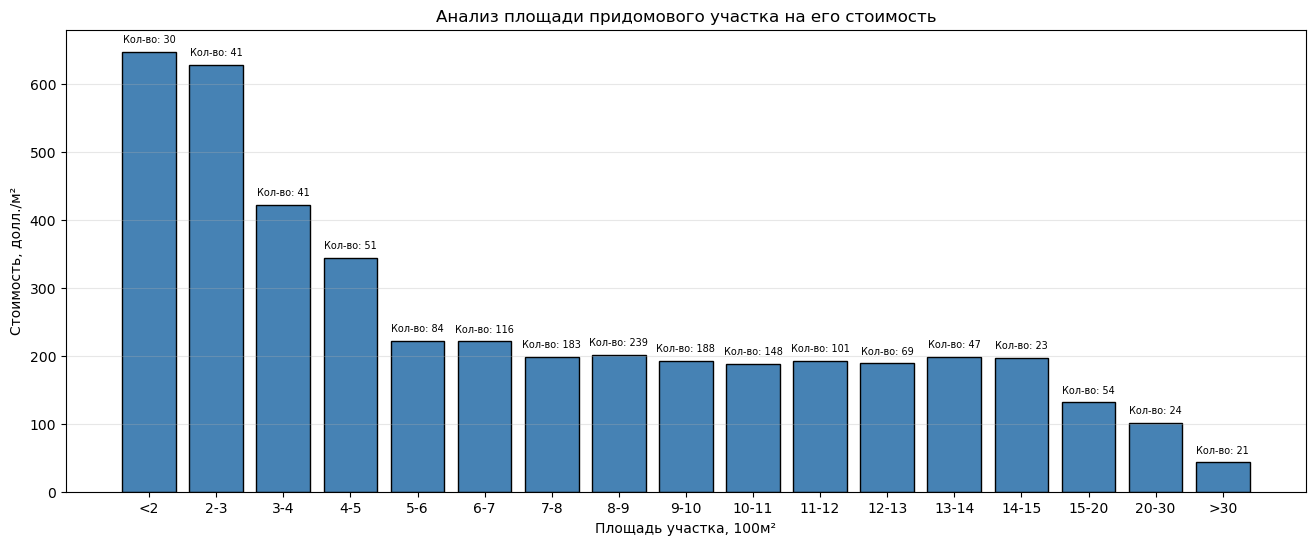

In [18]:
bins = [0, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 2000, 3000, float('inf')]
labels = ["<2", "2-3", "3-4", "4-5", "5-6", "6-7", "7-8", "8-9", "9-10", "10-11", "11-12", "12-13", "13-14", "14-15", "15-20", "20-30", ">30"]
our_df['LotArea_group'] = pd.cut(our_df['LotArea_m2'], bins=bins, labels=labels, right=False)

grouped = our_df.groupby('LotArea_group', observed=False)[['SalePrice', 'LotArea_m2']].mean()
prices = (grouped['SalePrice'] / grouped['LotArea_m2']).round(4)

counts = our_df.groupby('LotArea_group', observed=False).size()

plt.figure(figsize=(16, 6))
bars = plt.bar(prices.index, prices, color="steelblue", edgecolor="black")

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10.5, 
             f'Кол-во: {count}', ha='center', va='bottom', fontsize=7)
plt.xlabel("Площадь участка, 100м²")
plt.ylabel("Стоимость, долл./м²")
plt.title("Анализ площади придомового участка на его стоимость")
plt.grid(axis="y", alpha=0.3)
plt.show()

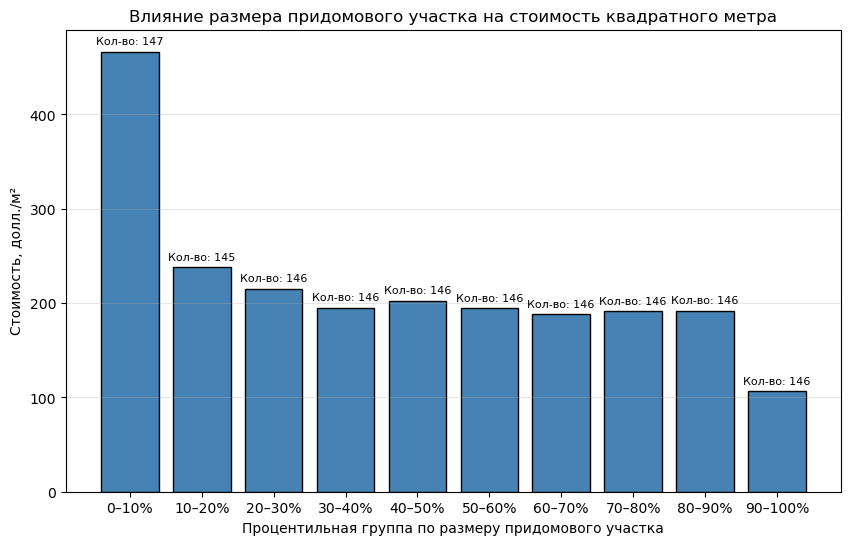

In [19]:
our_df['LotArea_group'] = pd.qcut(our_df['LotArea_m2'], q=10, labels=False)

grouped = our_df.groupby('LotArea_group')[['SalePrice', 'LotArea_m2']].mean()
prices = (grouped['SalePrice'] / grouped['LotArea_m2']).round(4)

counts = our_df.groupby('LotArea_group').size()

labels = [f"{i*10}–{(i+1)*10}%" for i in range(10)]

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, prices, color="steelblue", edgecolor="black")

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5.5,
             f'Кол-во: {count}', ha='center', va='bottom', fontsize=8)

plt.xlabel("Процентильная группа по размеру придомового участка")
plt.ylabel("Стоимость, долл./м²")
plt.title("Влияние размера придомового участка на стоимость квадратного метра")
plt.grid(axis="y", alpha=0.3)
plt.show()

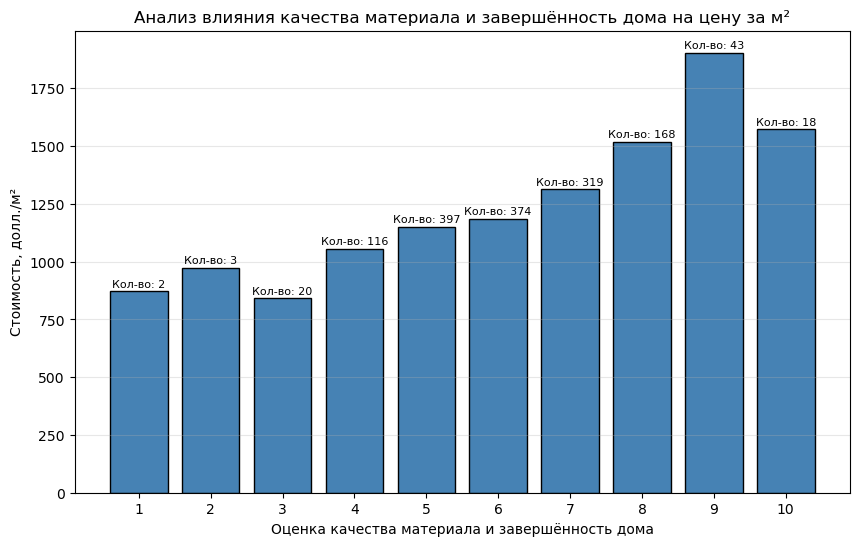

In [34]:
bins = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
labels = ["1", "2", "3", "4", "5", "6", "7", "8", "9", "10"]
our_df['OverallQual_group'] = pd.cut(our_df['OverallQual'], bins=bins, labels=labels, right=False)

grouped = our_df.groupby('OverallQual_group', observed=False)[['SalePrice', 'Area_m2']].mean()
prices = (grouped['SalePrice'] / grouped['Area_m2']).round(4)

counts = our_df.groupby('OverallQual_group', observed=False).size()

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, prices, color="steelblue", edgecolor="black")

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'Кол-во: {count}', ha='center', va='bottom', fontsize=8)

plt.xlabel("Оценка качества материала и завершённость дома")
plt.ylabel("Стоимость, долл./м²")
plt.title("Анализ влияния качества материала и завершённость дома на цену за м²")
plt.grid(axis="y", alpha=0.3)
plt.show()

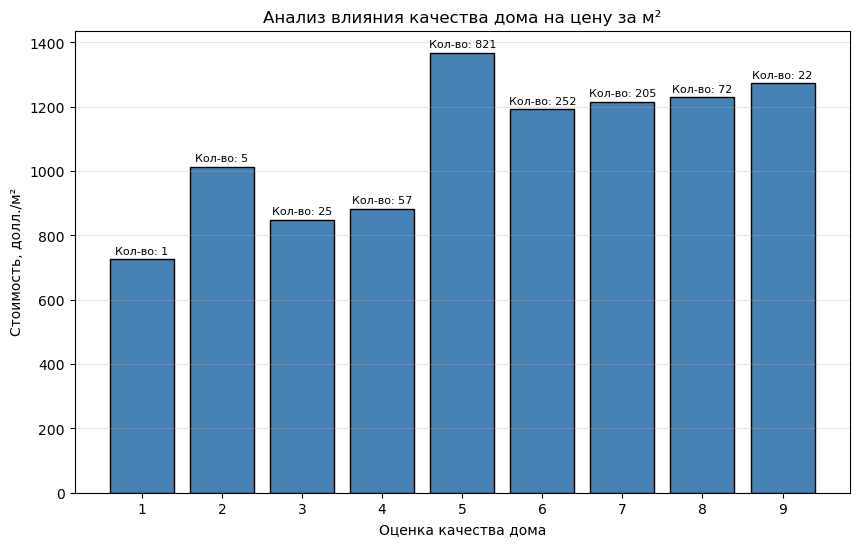

In [35]:
bins = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
labels = ["1", "2", "3", "4", "5", "6", "7", "8", "9", "10"]
our_df['OverallCond_group'] = pd.cut(our_df['OverallCond'], bins=bins, labels=labels, right=False)

grouped = our_df.groupby('OverallCond_group', observed=False)[['SalePrice', 'Area_m2']].mean()
prices = (grouped['SalePrice'] / grouped['Area_m2']).round(4)

counts = our_df.groupby('OverallCond_group', observed=False).size()

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, prices, color="steelblue", edgecolor="black")

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'Кол-во: {count}', ha='center', va='bottom', fontsize=8)

plt.xlabel("Оценка качества дома")
plt.ylabel("Стоимость, долл./м²")
plt.title("Анализ влияния качества дома на цену за м²")
plt.grid(axis="y", alpha=0.3)
plt.show()

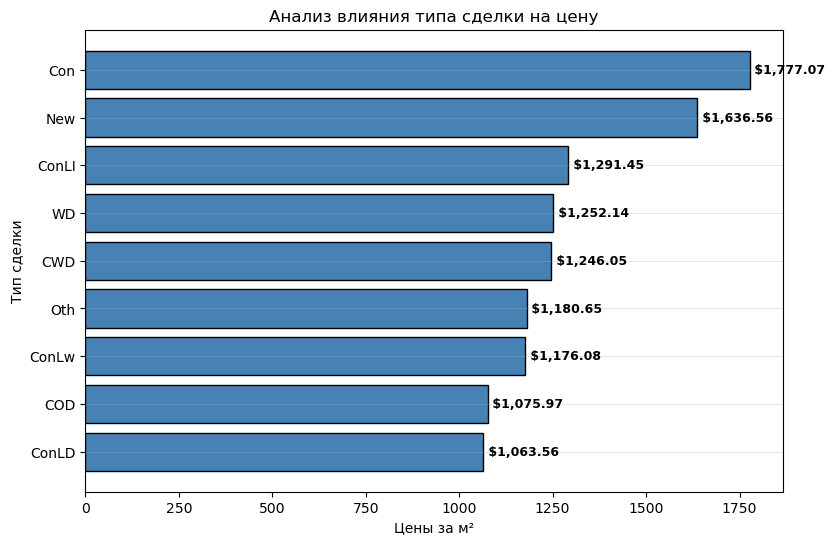

In [38]:
all_types = set(our_df["SaleType"])
prices = []
for type in all_types:
    curr_type = our_df[our_df["SaleType"] == type]
    price_type = round(
        float(curr_type["SalePrice"].mean() / curr_type["Area_m2"].mean()), 4
    )
    prices.append(price_type)
sorted_data = sorted(zip(prices, all_types))
sorted_prices , sorted_type  = zip(*sorted_data)
plt.figure(figsize=(9, 6))
plt.barh(list(sorted_type), sorted_prices, color="steelblue", edgecolor="black")
plt.xlabel("Цены за м²")
plt.ylabel("Тип сделки")
plt.title("Анализ влияния типа сделки на цену")
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(sorted_prices):
    plt.text(v + 2, i, f" ${v:,.2f}", va="center", fontsize=9, fontweight="bold")


plt.show()

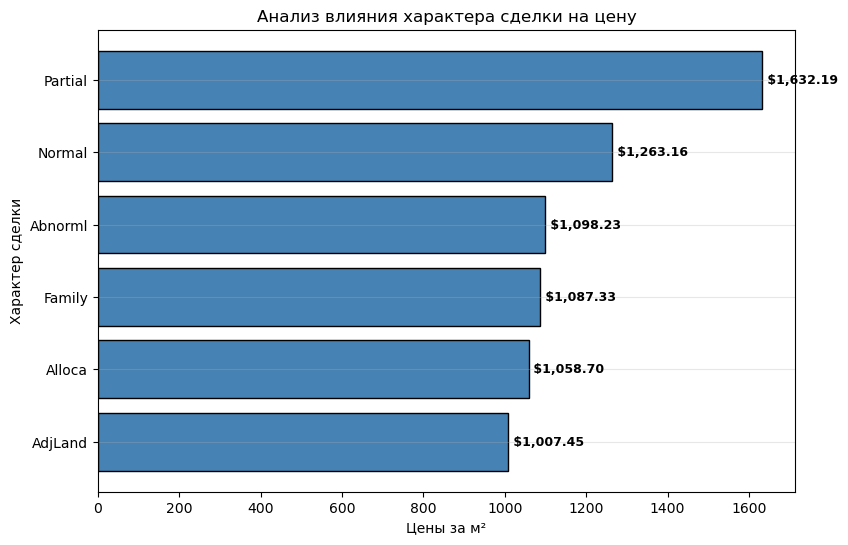

In [40]:
all_types = set(our_df["SaleCondition"])
prices = []
for type in all_types:
    curr_type = our_df[our_df["SaleCondition"] == type]
    price_type = round(
        float(curr_type["SalePrice"].mean() / curr_type["Area_m2"].mean()), 4
    )
    prices.append(price_type)
sorted_data = sorted(zip(prices, all_types))
sorted_prices , sorted_type  = zip(*sorted_data)
plt.figure(figsize=(9, 6))
plt.barh(list(sorted_type), sorted_prices, color="steelblue", edgecolor="black")
plt.xlabel("Цены за м²")
plt.ylabel("Характер сделки")
plt.title("Анализ влияния характера сделки на цену")
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(sorted_prices):
    plt.text(v + 2, i, f" ${v:,.2f}", va="center", fontsize=9, fontweight="bold")


plt.show()